In [70]:
import pandas as pd
import numpy as np
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
data = pd.read_excel("data/songlist.xlsx")

## 1. Data review

In [4]:
data

,name,artist,danceability,energy,loudness,acousticness,liveness,valence,tempo,popularity,duration_sec,genre
0,A Crisis Of Revelation,Trivium,27.1,97.8,-4.005,0.000729,13.80,34.70,106.042,53.0,335.792,metal
1,A Grey so Dark,Trivium,45.1,89.6,-3.396,0.058000,32.30,78.00,83.898,37.0,161.333,metal
2,A Gunshot to the Head of Trepidation,Trivium,25.4,95.2,-3.472,0.002680,20.90,48.10,145.024,46.0,355.320,metal
3,A Skyline's Severance,Trivium,18.7,97.3,-4.322,0.002840,31.20,36.00,185.035,39.0,292.160,metal
4,A View of Burning Empires,Trivium,23.9,38.8,-10.314,2.850000,53.40,8.99,142.567,24.0,109.907,metal
...,...,...,...,...,...,...,...,...,...,...,...,...
3085,rockstar,Post Malone,59.4,50.7,-6.141,14.500000,13.20,13.70,159.729,55.0,218.147,pop
3086,Staring At The Sun (feat. SZA),Post Malone,72.4,77.2,-4.389,25.000000,30.80,34.70,95.074,70.0,168.280,pop
3087,Stay,Post Malone,50.7,48.0,-5.418,44.900000,14.70,35.00,86.046,76.0,204.427,pop
3088,Take What You Want (feat. Ozzy Osbourne & Trav...,Post Malone,49.9,80.0,-2.665,9.060000,14.70,27.20,139.919,77.0,229.573,pop


In [83]:
data.groupby(["category", "genre"]).size()

category  genre
0         metal    109
          pop      536
          rock     104
1         metal    486
          pop       12
          rock      59
2         metal    122
          pop      511
          rock      96
3         metal     94
          pop      203
          rock      90
4         metal    442
          pop      115
          rock     111
dtype: int64

In [84]:
data.groupby(["genre"]).size()

genre
metal    1253
pop      1377
rock      460
dtype: int64

In [85]:
data.groupby(["category"]).size()

category
0    749
1    557
2    729
3    387
4    668
dtype: int64

In [63]:
type(data)

pandas.DataFrame

<Axes: >

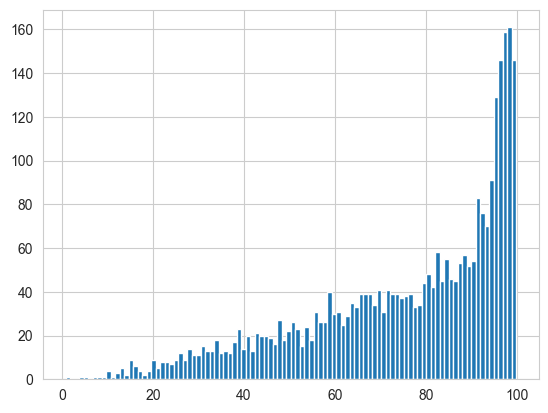

In [17]:
data["energy"].hist(bins=100)

<Axes: >

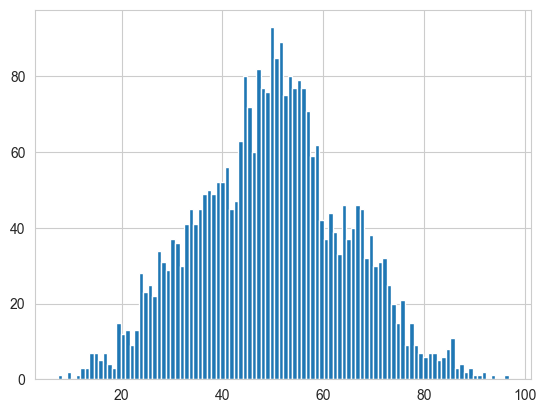

In [16]:
data["danceability"].hist(bins=100)

<Axes: >

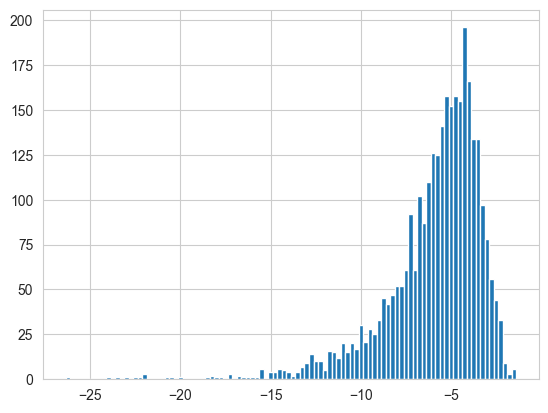

In [15]:
data["loudness"].hist(bins=100)

<Axes: >

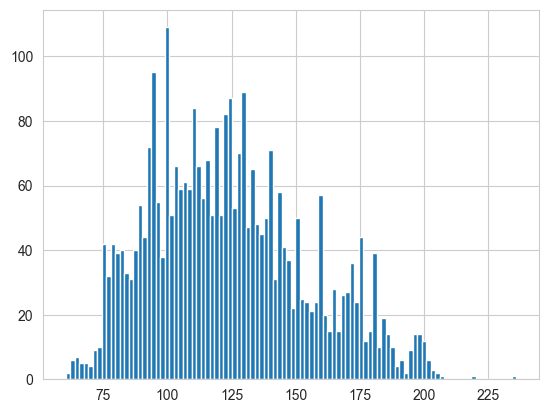

In [18]:
data["tempo"].hist(bins=100)

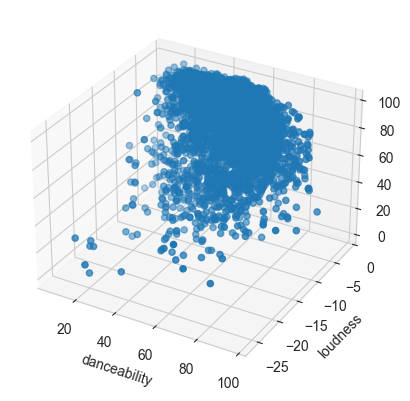

In [11]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(data["danceability"], data["loudness"], data["energy"])

ax.set_xlabel("danceability")
ax.set_ylabel("loudness")
ax.set_zlabel("energy")

plt.show()

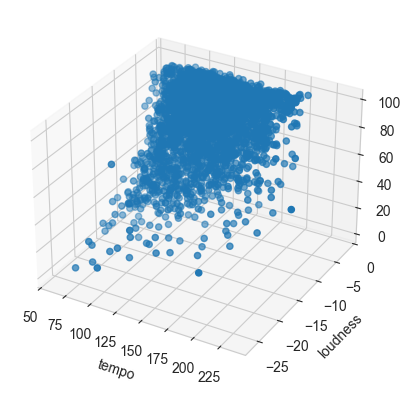

In [12]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(data["tempo"], data["loudness"], data["energy"])

ax.set_xlabel("tempo")
ax.set_ylabel("loudness")
ax.set_zlabel("energy")

plt.show()

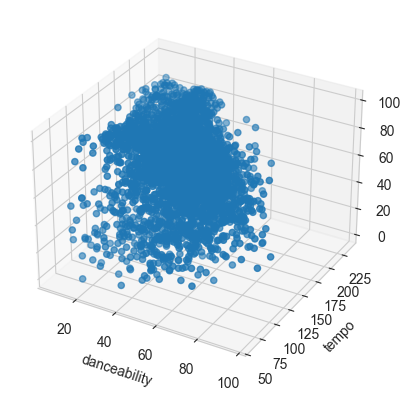

In [19]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(data["danceability"], data["tempo"], data["energy"])

ax.set_xlabel("danceability")
ax.set_ylabel("tempo")
ax.set_zlabel("energy")

plt.show()

## 2. Estimation

In [35]:
x = data[["danceability", "tempo", "energy", "loudness"]].to_numpy()
n, d = x.shape
L = 5 # number of components
w = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
mu = x[np.random.choice(n, L, replace=False)]
Sigma = np.array([np.cov(x.T) for _ in range(L)])
loglik = 0
max_attempts = 100

for j in range(max_attempts):
    # ---- E STEP ----
    pdf = np.zeros((n,L))

    for l in range(L):
        pdf[:,l] = multivariate_normal(mu[l], Sigma[l]).pdf(x)

    weighted = w * pdf
    pi = weighted / weighted.sum(axis=1, keepdims=True)

    Nk = pi.sum(axis=0)

    # ---- M STEP ----
    w = Nk / n

    mu_new = (pi.T @ x) / Nk[:,None]

    Sigma_new = np.zeros((L,d,d))

    for l in range(L):
        diff = x - mu_new[l]
        Sigma_new[l] = (pi[:,l][:,None] * diff).T @ diff / Nk[l]

    loglik_new = np.sum(np.log(weighted.sum(axis=1)))

    print(f"{j} W {w}, \nmu {mu_new},\n Sigma \n{Sigma_new},\n loglik {loglik_new}")

    if abs(loglik - loglik_new) < 1e-5:
        break

    loglik = loglik_new
    mu = mu_new
    Sigma = Sigma_new

0 W [0.09511331 0.30827575 0.10995998 0.20802985 0.27862111], 
mu [[ 33.91074885 158.84808956  79.28549276  -5.20059812]
 [ 52.65900009 111.61294195  83.24508041  -4.79544237]
 [ 59.60331888  97.5116325   49.78704193  -6.76874627]
 [ 45.48282167 113.83411494  74.24975353  -7.98790458]
 [ 51.26796511 143.5123085   75.38404575  -5.57217895]],
 Sigma 
[[[ 115.02807712  -53.42554805  -23.29760585    0.808592  ]
  [ -53.42554805  807.80923327  159.73383426    8.74603337]
  [ -23.29760585  159.73383426  432.10051142   35.80300466]
  [   0.808592      8.74603337   35.80300466    4.73146816]]

 [[ 171.91051711   24.32698507  -59.40702387   -2.96769838]
  [  24.32698507  440.48290625   30.9999214     2.79571296]
  [ -59.40702387   30.9999214   243.49952106   19.11064575]
  [  -2.96769838    2.79571296   19.11064575    2.67969039]]

 [[ 223.7809841   100.81227801   65.987915      6.81210272]
  [ 100.81227801  337.92016418   60.86736436    8.17477753]
  [  65.987915     60.86736436  335.4755825  

## 3. Estimation with library

In [36]:
from sklearn.mixture import GaussianMixture

X = x

gmm = GaussianMixture(
    n_components=5,
    covariance_type='full',
    random_state=0
)

gmm.fit(X)

,"n_components n_components: int, default=1The number of mixture components.",5
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",0


In [37]:
gmm.weights_

array([0.18086206, 0.16705787, 0.12152521, 0.15508066, 0.3754742 ])

In [38]:
gmm.means_

array([[ 55.15860443, 121.36215972,  86.94322842,  -4.54404314],
       [ 45.85666852, 100.39846715,  51.46621079,  -9.47583549],
       [ 39.25103372, 160.86732002,  95.47062574,  -4.81907532],
       [ 43.95901537, 106.73152466,  96.95326838,  -4.08899684],
       [ 54.69073116, 130.71834533,  64.36566714,  -6.14392096]])

In [39]:
gmm.covariances_

array([[[ 1.29885132e+02, -4.57317705e+01, -3.22637258e+01,
         -1.45804735e+00],
        [-4.57317705e+01,  4.52720183e+02,  3.88641021e+01,
          3.99774553e+00],
        [-3.22637258e+01,  3.88641021e+01,  4.12350940e+01,
          3.14511014e+00],
        [-1.45804735e+00,  3.99774553e+00,  3.14511014e+00,
          9.65131617e-01]],

       [[ 2.33516415e+02,  7.18126156e+01, -1.90920572e+01,
          1.43273811e+00],
        [ 7.18126156e+01,  5.18978669e+02,  1.05439329e+02,
         -1.26275556e+01],
        [-1.90920572e+01,  1.05439329e+02,  5.63449746e+02,
          5.01462982e+01],
        [ 1.43273811e+00, -1.26275556e+01,  5.01462982e+01,
          1.37389676e+01]],

       [[ 1.02646171e+02, -1.08226475e+02, -5.15179275e+00,
         -2.31754518e+00],
        [-1.08226475e+02,  6.05554338e+02,  3.34949169e+01,
          2.28479785e+01],
        [-5.15179275e+00,  3.34949169e+01,  8.15838499e+00,
          2.95486167e+00],
        [-2.31754518e+00,  2.28479785e+

In [40]:
gmm.score(X)          # average log likelihood

-14.80109746430717

## Clustering
["danceability", "tempo", "energy", "loudness"]

In [46]:
mu[0]

array([ 51.54377472, 139.73855212,  60.71710091,  -6.58562033])

In [47]:
mu

array([[ 51.54377472, 139.73855212,  60.71710091,  -6.58562033],
       [ 43.90806461, 108.93032975,  96.96401614,  -4.13989442],
       [ 59.92840768, 105.59002601,  75.28733172,  -5.19111462],
       [ 45.1619681 , 100.98142733,  50.40639805,  -9.94911379],
       [ 44.55478592, 150.29347724,  92.67773565,  -4.58292565]])

In [49]:
Sigma[0]

array([[ 2.17183295e+02, -1.85111354e+02, -4.52684595e+01,
         1.34096400e-01],
       [-1.85111354e+02,  7.79979600e+02,  1.61997998e+02,
         6.65521654e+00],
       [-4.52684595e+01,  1.61997998e+02,  3.17200415e+02,
         2.71721635e+01],
       [ 1.34096400e-01,  6.65521654e+00,  2.71721635e+01,
         4.49861811e+00]])

In [52]:
pdf = np.zeros((n,L))
for l in range(L):
        pdf[:,l] = multivariate_normal(mu[l], Sigma[l]).pdf(x)
weighted = w * pdf

In [57]:
pi = weighted / weighted.sum(axis=1, keepdims=True)

In [51]:
pdf

array([[2.29556224e-009, 1.73040639e-005, 2.38159211e-007,
        6.58837952e-008, 2.82823284e-009],
       [7.69216696e-009, 2.03307934e-009, 1.23334824e-006,
        7.60320161e-008, 2.20674090e-008],
       [7.11511754e-008, 2.10129144e-007, 4.41515914e-010,
        6.11199530e-009, 8.31248873e-007],
       ...,
       [1.03920453e-007, 1.88614456e-173, 5.93658501e-008,
        3.38637183e-007, 4.52457650e-031],
       [4.65357688e-007, 4.03106417e-030, 1.84872654e-008,
        2.16146341e-008, 1.17684786e-008],
       [1.24102016e-006, 9.05206920e-121, 2.55312562e-007,
        1.54907486e-007, 3.61898191e-022]], shape=(3090, 5))

In [56]:
weighted

array([[6.09342597e-010, 2.85820427e-006, 5.22088120e-008,
        9.29202212e-009, 5.91457899e-010],
       [2.04183747e-009, 3.35814527e-010, 2.70372269e-007,
        1.07232920e-008, 4.61487582e-009],
       [1.88866332e-008, 3.47081483e-008, 9.67882839e-011,
        8.62014633e-010, 1.73836010e-007],
       ...,
       [2.75850324e-008, 3.11544529e-174, 1.30140694e-008,
        4.77602145e-008, 9.46207989e-032],
       [1.23526279e-007, 6.65832308e-031, 4.05274338e-009,
        3.04845308e-009, 2.46109852e-009],
       [3.29421017e-007, 1.49517841e-121, 5.59691372e-008,
        2.18476149e-008, 7.56824336e-023]], shape=(3090, 5))

In [60]:
pi

array([[2.08614250e-004, 9.78533497e-001, 1.78741848e-002,
        3.18121241e-003, 2.02491254e-004],
       [7.08754561e-003, 1.16566613e-003, 9.38505546e-001,
        3.72222679e-002, 1.60189747e-002],
       [8.26948060e-002, 1.51969044e-001, 4.23785874e-004,
        3.77431658e-003, 7.61138048e-001],
       ...,
       [3.12191555e-001, 3.52588207e-167, 1.47285764e-001,
        5.40522681e-001, 1.07086386e-024],
       [9.28150895e-001, 5.00292615e-024, 3.04514749e-002,
        2.29054455e-002, 1.84921849e-002],
       [8.08915680e-001, 3.67151215e-115, 1.37436018e-001,
        5.36483023e-002, 1.85843356e-016]], shape=(3090, 5))

In [62]:
indices = pi.argmax(axis=1)
indices

array([1, 2, 4, ..., 3, 0, 0], shape=(3090,))

In [64]:
indices.shape

(3090,)

In [65]:
data["category"] = indices

In [75]:
data[data["artist"] == "Lamb of God"]

,name,artist,danceability,energy,loudness,acousticness,liveness,valence,tempo,popularity,duration_sec,genre,category
400,11th Hour,Lamb of God,31.8,98.1,-3.583,0.00118,31.50,20.50,101.762,41.0,224.093,metal,1
401,512,Lamb of God,16.2,97.0,-4.638,0.00160,8.75,11.50,192.277,48.0,284.840,metal,4
402,A Devil In God's Country,Lamb of God,43.6,98.9,-3.334,0.01490,26.40,44.50,94.103,31.0,194.600,metal,1
403,A Warning,Lamb of God,22.8,95.8,-3.135,0.00345,46.90,70.60,176.741,31.0,143.653,metal,4
404,Again We Rise,Lamb of God,43.1,99.4,-3.743,0.00912,11.50,6.17,110.268,47.0,270.440,metal,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
493,Vigil,Lamb of God,32.6,94.9,-5.027,0.02000,9.10,12.00,106.145,40.0,283.000,metal,1
494,Visitation,Lamb of God,38.3,98.8,-3.001,0.00310,34.60,12.40,147.258,28.0,239.013,metal,4
495,Walk with Me In Hell,Lamb of God,28.6,98.2,-3.828,0.00339,30.90,11.80,110.629,60.0,311.507,metal,1
496,What I've Become,Lamb of God,27.5,98.7,-3.414,0.01570,18.70,19.10,95.322,43.0,208.793,metal,1


In [72]:
data[["name", "artist", "category"]]

,name,artist,category
0,A Crisis Of Revelation,Trivium,1
1,A Grey so Dark,Trivium,2
2,A Gunshot to the Head of Trepidation,Trivium,4
3,A Skyline's Severance,Trivium,4
4,A View of Burning Empires,Trivium,0
...,...,...,...
3085,rockstar,Post Malone,0
3086,Staring At The Sun (feat. SZA),Post Malone,2
3087,Stay,Post Malone,3
3088,Take What You Want (feat. Ozzy Osbourne & Trav...,Post Malone,0


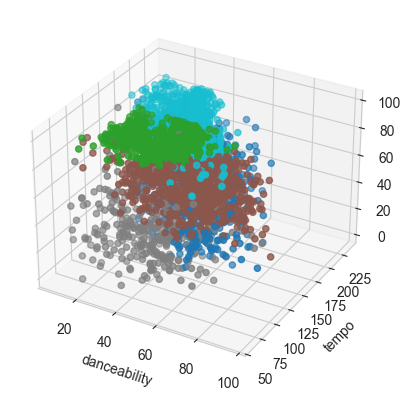

In [67]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

sc = ax.scatter(
    data["danceability"],
    data["tempo"],
    data["energy"],
    c=data["category"],   # color by category
    cmap="tab10"          # good for discrete categories
)

ax.set_xlabel("danceability")
ax.set_ylabel("tempo")
ax.set_zlabel("energy")

plt.show()

In [69]:
fig = px.scatter_3d(
    data,
    x="danceability",
    y="tempo",
    z="energy",
    color="category"
)

fig.show()

In [71]:
fig = px.scatter_3d(
    data,
    x="loudness",
    y="tempo",
    z="energy",
    color="category"
)

fig.show()

<Axes: xlabel='energy', ylabel='loudness'>

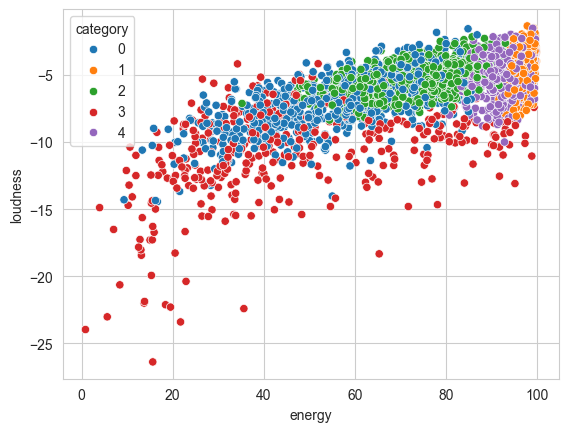

In [76]:
import seaborn as sns

sns.scatterplot(
    data=data,
    x="energy",
    y="loudness",
    hue="category",
    palette="tab10"
)

In [86]:
data[["name", "artist", "category"]].to_csv("file.csv")